Initial exploratory books.csv data analysis!!

pandas is the main library we will use for working with the table.



In [63]:
import pandas as pd

Load books.csv


In [64]:
df = pd.read_csv("../data/raw/books.csv") #loads in books.csv as a pandas dataframe

#Because the notebook is inside notebooks, ../data/raw/ points to the raw folder.


Examine dataframe through some preliminary data exploration

In [65]:
df.head() #returns first 5 rows of dataframe


,book_id,title,author,genres,publication_year,page_count,average_rating,rating_count,description
0,B001,Dune,Frank Herbert,Science Fiction;Politics;Adventure,1965,412,4.27,850000,A young nobleman becomes entangled in a strugg...
1,B002,Hyperion,Dan Simmons,Science Fiction;Space Opera;Adventure,1989,482,4.22,185000,Seven travelers journey toward a mysterious wo...
2,B003,The Left Hand of Darkness,Ursula K. Le Guin,Science Fiction;Politics;Literary,1969,304,4.08,190000,An envoy visits a distant planet and must navi...
3,B004,The Dispossessed,Ursula K. Le Guin,Science Fiction;Politics;Literary,1974,387,4.23,170000,A physicist moves between contrasting worlds w...
4,B005,Foundation,Isaac Asimov,Science Fiction;Space Opera;Politics,1951,296,4.17,500000,A mathematician predicts the collapse of a vas...


In [66]:
df.tail() #looks at last 5 rows of df

,book_id,title,author,genres,publication_year,page_count,average_rating,rating_count,description
95,B096,East of Eden,John Steinbeck,Historical;Family;Literary,1952,601,4.38,850000,Two generations of intertwined families confro...
96,B097,The Count of Monte Cristo,Alexandre Dumas,Classic;Adventure;Revenge,1844,1276,4.75,900000,"A wrongfully imprisoned sailor escapes, acquir..."
97,B098,The Shadow of the Wind,Carlos Ruiz Zafon,Mystery;Historical;Literary,2001,487,4.27,700000,A boy discovers a mysterious novel in a secret...
98,B099,The Secret History,Donna Tartt,Mystery;Literary;Crime,1992,559,4.16,750000,A college student joins an exclusive classics ...
99,B100,The Midnight Library,Matt Haig,Fantasy;Contemporary;Philosophical,2020,304,4.02,1200000,A woman given the chance to explore alternate ...


In [67]:
df.shape

#result is (rows, columns)

(100, 9)

In [68]:
df.columns #gives all column names in dataframe

list(df.columns) #formats output of command to be iterable/readable

#now we understand what information is available to us!

['book_id',
 'title',
 'author',
 'genres',
 'publication_year',
 'page_count',
 'average_rating',
 'rating_count',
 'description']

In [69]:
df.describe()

#gives us some summary statistics

,publication_year,page_count,average_rating,rating_count
count,100.000000,100.000000,100.00000,1.000000e+02
mean,1985.910000,464.440000,4.22040,1.191350e+06
std,41.676749,208.777941,0.18658,1.303323e+06
min,1813.000000,180.000000,3.80000,1.000000e+05
25%,1967.000000,315.750000,4.07750,4.500000e+05
50%,2005.000000,411.000000,4.22000,8.000000e+05
75%,2014.000000,537.250000,4.34000,1.225000e+06
max,2021.000000,1276.000000,4.76000,8.500000e+06


In [70]:
#we can describe some individual columns as well

print(df["page_count"].describe())
df["average_rating"].describe()


count     100.000000
mean      464.440000
std       208.777941
min       180.000000
25%       315.750000
50%       411.000000
75%       537.250000
max      1276.000000
Name: page_count, dtype: float64


count    100.00000
mean       4.22040
std        0.18658
min        3.80000
25%        4.07750
50%        4.22000
75%        4.34000
max        4.76000
Name: average_rating, dtype: float64

In [71]:
df.loc[df["page_count"].idxmax()]

#df[col_name].idxmax() locates the row with the maximum col value, df.loc gives all information in row

book_id                                                          B097
title                                       The Count of Monte Cristo
author                                                Alexandre Dumas
genres                                      Classic;Adventure;Revenge
publication_year                                                 1844
page_count                                                       1276
average_rating                                                   4.75
rating_count                                                   900000
description         A wrongfully imprisoned sailor escapes, acquir...
Name: 96, dtype: object

In [72]:
df.loc[df["average_rating"].idxmax()]

book_id                                                          B017
title                                               Words of Radiance
author                                              Brandon Sanderson
genres                                             Fantasy;Epic;Magic
publication_year                                                 2014
page_count                                                       1087
average_rating                                                   4.76
rating_count                                                   650000
description         A growing group of magical warriors and leader...
Name: 16, dtype: object

In [73]:
df["author"].value_counts().head(10)

#gives a list of the top ten authors with the most books in this dataset

Ursula K. Le Guin    3
N. K. Jemisin        3
Brandon Sanderson    3
J. R. R. Tolkien     3
Patrick Rothfuss     2
Octavia E. Butler    2
Madeline Miller      2
Andy Weir            2
Agatha Christie      2
Donna Tartt          2
Name: author, dtype: int64

We have done some very general data exploration, now let's explore genre more specifically.

We saw earlier that genres are separated by semicolon. Let's count how many genres there are in this dataset.

In [74]:
genres = df["genres"].str.split(";") #creating a new df that has an array/list of genres
genres

genre_counts= (genres.explode().value_counts()) #.explode() turns every element of each genre list into their own rows, where every other value is the same.
#basically, if a book has 3 genres(romance, fantasy, scifi), that book now has 3 rows, one for each genre

genre_counts

Literary           29
Fantasy            24
Historical         23
Classic            18
Science Fiction    17
                   ..
Migration           1
Immigration         1
Character           1
Physics             1
Philosophical       1
Name: genres, Length: 68, dtype: int64

Now let's check for any missing data and duplicates. Something to keep in mind is that book_id is a unique signifier, meaning that even if there are duplicate books in our data, they will be represented by different book_id values. So, there will never be any true duplicates. We will have to check for duplicates in a way that doesn't take book_id into account.

In [84]:
#check for any missing data

df.isna().sum()


book_id             0
title               0
author              0
genres              0
publication_year    0
page_count          0
average_rating      0
rating_count        0
description         0
dtype: int64

In [76]:
df["title"].duplicated().sum()
df[df['title'].duplicated(keep=False)]

,book_id,title,author,genres,publication_year,page_count,average_rating,rating_count,description
18,B019,The Hobbit,J. R. R. Tolkien,Fantasy;Adventure;Classic,1937,310,4.29,2100000,A reluctant hobbit leaves home with a company ...
60,B061,The Hobbit,J. R. R. Tolkien,Fantasy;Adventure;Classic,1937,310,4.29,2100000,A reluctant hobbit leaves home with a company ...


We see one duplicate: "The Hobbit." See how even though these are identical entries, the values for book_id are different?

In [77]:
df.drop(columns=["book_id"]).duplicated().sum() #this returns the number of identical pairs of rows without taking into account book_id
#returns 1; there is one extra row whose book metadata matches an earlier row, ignoring the ID

df[
    df.drop(columns=["book_id"]).duplicated(keep=False) #to inspect both rows
].sort_values("title")

,book_id,title,author,genres,publication_year,page_count,average_rating,rating_count,description
18,B019,The Hobbit,J. R. R. Tolkien,Fantasy;Adventure;Classic,1937,310,4.29,2100000,A reluctant hobbit leaves home with a company ...
60,B061,The Hobbit,J. R. R. Tolkien,Fantasy;Adventure;Classic,1937,310,4.29,2100000,A reluctant hobbit leaves home with a company ...


The code below tells pandas to identify duplicates using every column except book_id; it keeps the first occurrence and drops the second.

It's important to note that we store this 'cleaned' code in a new dataframe, leaving the original untouched. This is good practice. We'll use the cleaned dataset for further exploration, and save it for future use.


In [78]:
df_clean = df.drop_duplicates(
    subset=df.columns.drop("book_id").tolist()
)

Now let's verify.

In [79]:
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))

print(
    "Duplicates excluding book_id:",
    df_clean.drop(columns=["book_id"]).duplicated().sum()
)

Original rows: 100
Cleaned rows: 99
Duplicates excluding book_id: 0


This tracks with what we found earlier in our exploration. 

Now for some visualizations:

<function matplotlib.pyplot.show(close=None, block=None)>

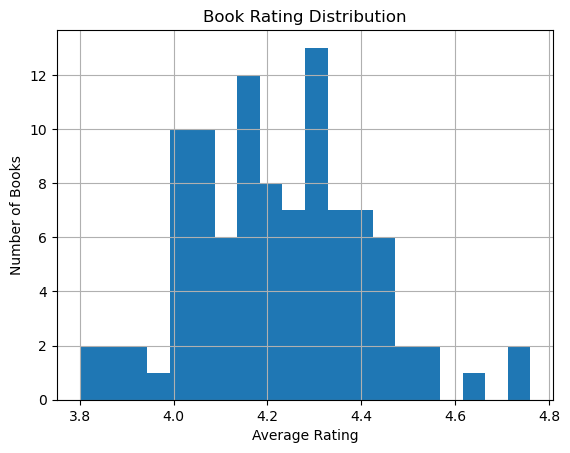

In [80]:
import matplotlib.pyplot as plt

df_clean["average_rating"].hist(bins=20)
plt.xlabel("Average Rating")
plt.ylabel("Number of Books")
plt.title("Book Rating Distribution")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

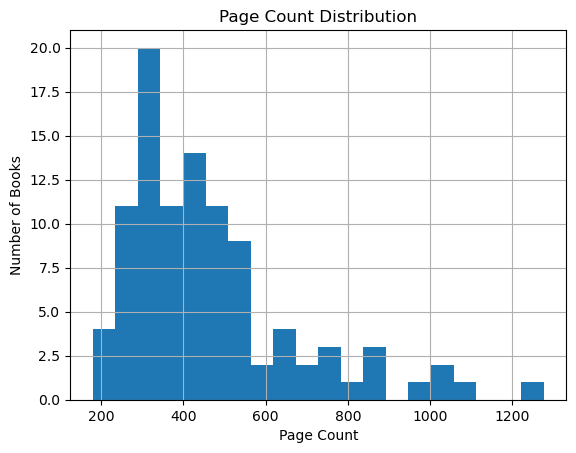

In [81]:
df_clean["page_count"].hist(bins=20)
plt.xlabel("Page Count")
plt.ylabel("Number of Books")
plt.title("Page Count Distribution")
plt.show

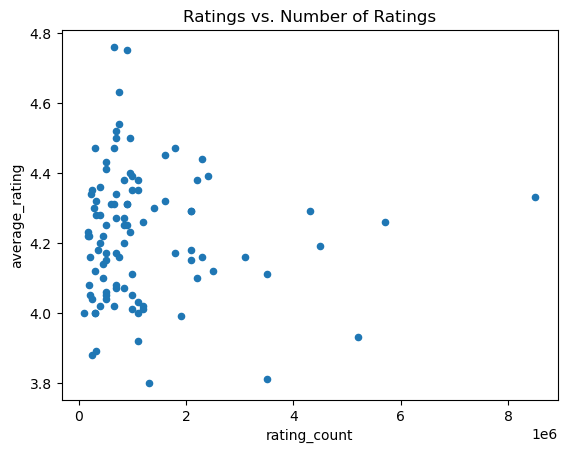

In [82]:
df_clean.plot.scatter(x="rating_count", y="average_rating")
plt.title("Ratings vs. Number of Ratings")
plt.show()

Now answer the next 10 questions on your own:

1. What are the 10 longest books?
2. What are the 10 highest-rated books?
3. What are the highest-rated books with at least 500,000 ratings?
4. Which books were published after 2010?
5. Which books are by Ursula K. Le Guin?
6. What is the average page count by author?
7. What is the average rating by author?
8. Can you make a DataFrame containing only title, author, average_rating, and page_count?


Useful operations: sort_values(), loc[], groupby(), value_counts(), head(), and query().


In [89]:
list(df_clean.columns)

['book_id',
 'title',
 'author',
 'genres',
 'publication_year',
 'page_count',
 'average_rating',
 'rating_count',
 'description']

In [88]:
#numba 1
longest_books = df_clean.sort_values(by="page_count", ascending=False)
longest_books.head(10)

,book_id,title,author,genres,publication_year,page_count,average_rating,rating_count,description
96,B097,The Count of Monte Cristo,Alexandre Dumas,Classic;Adventure;Revenge,1844,1276,4.75,900000,"A wrongfully imprisoned sailor escapes, acquir..."
16,B017,Words of Radiance,Brandon Sanderson,Fantasy;Epic;Magic,2014,1087,4.76,650000,A growing group of magical warriors and leader...
23,B024,Jonathan Strange & Mr Norrell,Susanna Clarke,Fantasy;Historical;Literary,2004,1024,4.30,280000,Two very different magicians revive English ma...
15,B016,The Way of Kings,Brandon Sanderson,Fantasy;Epic;Magic,2010,1007,4.63,750000,Several characters struggle to survive a bruta...
14,B015,The Wise Man's Fear,Patrick Rothfuss,Fantasy;Magic;Adventure,2011,994,4.54,750000,The continuing account of a gifted young man's...
24,B025,The Priory of the Orange Tree,Samantha Shannon,Fantasy;Epic;Dragons,2019,848,4.16,210000,"Queens, dragon riders, scholars, and hidden en..."
94,B095,Lonesome Dove,Larry McMurtry,Western;Historical;Adventure,1985,843,4.52,700000,Two aging Texas Rangers lead a cattle drive no...
45,B046,Middlemarch,George Eliot,Classic;Literary;Romance,1871,838,4.04,250000,Several interconnected lives reveal the ambiti...
63,B064,The Pillars of the Earth,Ken Follett,Historical;Epic;Politics,1989,806,4.31,900000,"Builders, nobles, clergy, and ordinary people ..."
87,B088,The Goldfinch,Donna Tartt,Literary;Coming of Age;Crime,2013,771,3.92,1100000,"After surviving a museum bombing, a boy become..."


In [90]:
#numba 2
df_clean.sort_values(by="average_rating", ascending=False).head(10)

,book_id,title,author,genres,publication_year,page_count,average_rating,rating_count,description
16,B017,Words of Radiance,Brandon Sanderson,Fantasy;Epic;Magic,2014,1087,4.76,650000,A growing group of magical warriors and leader...
96,B097,The Count of Monte Cristo,Alexandre Dumas,Classic;Adventure;Revenge,1844,1276,4.75,900000,"A wrongfully imprisoned sailor escapes, acquir..."
15,B016,The Way of Kings,Brandon Sanderson,Fantasy;Epic;Magic,2010,1007,4.63,750000,Several characters struggle to survive a bruta...
14,B015,The Wise Man's Fear,Patrick Rothfuss,Fantasy;Magic;Adventure,2011,994,4.54,750000,The continuing account of a gifted young man's...
94,B095,Lonesome Dove,Larry McMurtry,Western;Historical;Adventure,1985,843,4.52,700000,Two aging Texas Rangers lead a cattle drive no...
13,B014,The Name of the Wind,Patrick Rothfuss,Fantasy;Magic;Coming of Age,2007,662,4.50,950000,"A gifted musician recounts the early life, edu..."
6,B007,Project Hail Mary,Andy Weir,Science Fiction;Space;Adventure,2021,496,4.50,700000,An astronaut awakens alone on a desperate miss...
71,B072,Educated,Tara Westover,Memoir;Education;Family,2018,334,4.47,1800000,A woman raised in an isolated family pursues e...
69,B070,The Warmth of Other Suns,Isabel Wilkerson,History;Migration;Nonfiction,2010,622,4.47,300000,Three people leave the American South and beco...
17,B018,Mistborn: The Final Empire,Brandon Sanderson,Fantasy;Magic;Rebellion,2006,541,4.47,650000,A street thief joins a revolutionary plan to o...


In [97]:
#highest rated books with at least 500,000 ratings.

df_clean.loc[df_clean['rating_count']>=500000].sort_values(by='average_rating', ascending= False).head(10)

,book_id,title,author,genres,publication_year,page_count,average_rating,rating_count,description
16,B017,Words of Radiance,Brandon Sanderson,Fantasy;Epic;Magic,2014,1087,4.76,650000,A growing group of magical warriors and leader...
96,B097,The Count of Monte Cristo,Alexandre Dumas,Classic;Adventure;Revenge,1844,1276,4.75,900000,"A wrongfully imprisoned sailor escapes, acquir..."
15,B016,The Way of Kings,Brandon Sanderson,Fantasy;Epic;Magic,2010,1007,4.63,750000,Several characters struggle to survive a bruta...
14,B015,The Wise Man's Fear,Patrick Rothfuss,Fantasy;Magic;Adventure,2011,994,4.54,750000,The continuing account of a gifted young man's...
94,B095,Lonesome Dove,Larry McMurtry,Western;Historical;Adventure,1985,843,4.52,700000,Two aging Texas Rangers lead a cattle drive no...
6,B007,Project Hail Mary,Andy Weir,Science Fiction;Space;Adventure,2021,496,4.50,700000,An astronaut awakens alone on a desperate miss...
13,B014,The Name of the Wind,Patrick Rothfuss,Fantasy;Magic;Coming of Age,2007,662,4.50,950000,"A gifted musician recounts the early life, edu..."
17,B018,Mistborn: The Final Empire,Brandon Sanderson,Fantasy;Magic;Rebellion,2006,541,4.47,650000,A street thief joins a revolutionary plan to o...
71,B072,Educated,Tara Westover,Memoir;Education;Family,2018,334,4.47,1800000,A woman raised in an isolated family pursues e...
46,B047,The Seven Husbands of Evelyn Hugo,Taylor Jenkins Reid,Historical;Romance;Celebrity,2017,400,4.45,1600000,An aging Hollywood star chooses an unknown wri...


In [98]:
#books published after 2010

df_clean.loc[df_clean['publication_year'] >= 2010]

,book_id,title,author,genres,publication_year,page_count,average_rating,rating_count,description
5,B006,The Martian,Andy Weir,Science Fiction;Survival;Adventure,2011,369,4.40,950000,An astronaut stranded on Mars uses engineering...
6,B007,Project Hail Mary,Andy Weir,Science Fiction;Space;Adventure,2021,496,4.50,700000,An astronaut awakens alone on a desperate miss...
10,B011,The Fifth Season,N. K. Jemisin,Fantasy;Climate;Epic,2015,512,4.32,330000,A world shattered by catastrophic geological e...
11,B012,The Obelisk Gate,N. K. Jemisin,Fantasy;Climate;Epic,2016,410,4.35,250000,Survivors struggle to control dangerous earth-...
12,B013,The Stone Sky,N. K. Jemisin,Fantasy;Climate;Epic,2017,416,4.34,220000,A mother and daughter confront the history beh...
14,B015,The Wise Man's Fear,Patrick Rothfuss,Fantasy;Magic;Adventure,2011,994,4.54,750000,The continuing account of a gifted young man's...
15,B016,The Way of Kings,Brandon Sanderson,Fantasy;Epic;Magic,2010,1007,4.63,750000,Several characters struggle to survive a bruta...
16,B017,Words of Radiance,Brandon Sanderson,Fantasy;Epic;Magic,2014,1087,4.76,650000,A growing group of magical warriors and leader...
22,B023,The Poppy War,R. F. Kuang,Fantasy;War;Historical,2018,544,4.14,450000,An orphan enters an elite military academy and...
24,B025,The Priory of the Orange Tree,Samantha Shannon,Fantasy;Epic;Dragons,2019,848,4.16,210000,"Queens, dragon riders, scholars, and hidden en..."


In [109]:
#books by Ursula K Le Guin

df_clean.loc[df_clean['author'] == 'Ursula K. Le Guin']

,book_id,title,author,genres,publication_year,page_count,average_rating,rating_count,description
2,B003,The Left Hand of Darkness,Ursula K. Le Guin,Science Fiction;Politics;Literary,1969,304,4.08,190000,An envoy visits a distant planet and must navi...
3,B004,The Dispossessed,Ursula K. Le Guin,Science Fiction;Politics;Literary,1974,387,4.23,170000,A physicist moves between contrasting worlds w...
27,B028,A Wizard of Earthsea,Ursula K. Le Guin,Fantasy;Magic;Coming of Age,1968,205,4.28,400000,A proud young wizard learns that mastering mag...


In [110]:
#What is the average page count by author?

df_clean.groupby('author')["page_count"].mean()

author
Agatha Christie       288.000000
Aldous Huxley         268.000000
Alex Michaelides      336.000000
Alexandre Dumas      1276.000000
Amor Towles           527.000000
                        ...     
Ursula K. Le Guin     298.666667
V. E. Schwab          448.000000
William Gibson        271.000000
Yaa Gyasi             305.000000
Yuval Noah Harari     443.000000
Name: page_count, Length: 84, dtype: float64

In [111]:
#What is the average rating by author?

df_clean.groupby('author')['average_rating'].mean()

author
Agatha Christie      4.255000
Aldous Huxley        3.990000
Alex Michaelides     4.170000
Alexandre Dumas      4.750000
Amor Towles          4.275000
                       ...   
Ursula K. Le Guin    4.196667
V. E. Schwab         4.200000
William Gibson       3.890000
Yaa Gyasi            4.430000
Yuval Noah Harari    4.390000
Name: average_rating, Length: 84, dtype: float64

In [119]:
#8. Can you make a DataFrame containing only title, author, average_rating, and page_count?
new_df = df_clean[['title','author','average_rating','page_count']]
new_df

,title,author,average_rating,page_count
0,Dune,Frank Herbert,4.27,412
1,Hyperion,Dan Simmons,4.22,482
2,The Left Hand of Darkness,Ursula K. Le Guin,4.08,304
3,The Dispossessed,Ursula K. Le Guin,4.23,387
4,Foundation,Isaac Asimov,4.17,296
...,...,...,...,...
95,East of Eden,John Steinbeck,4.38,601
96,The Count of Monte Cristo,Alexandre Dumas,4.75,1276
97,The Shadow of the Wind,Carlos Ruiz Zafon,4.27,487
98,The Secret History,Donna Tartt,4.16,559
